In [3]:
!pip install scikit-learn
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------------------- -------------------- 3.9/8.3 MB 26.2 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.3 MB 22.2 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 20.5 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn

In [4]:
TEST_PATH = "../data/classification/test"

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 375 images belonging to 25 classes.


In [5]:
vgg_model = tf.keras.models.load_model("../models/vgg16_model.h5")
resnet_model = tf.keras.models.load_model("../models/resnet50_model.h5")
mobilenet_model = tf.keras.models.load_model("../models/mobilenet_model.h5")
efficient_model = tf.keras.models.load_model("../models/efficientnet_model.h5")

In [6]:
vgg_acc = vgg_model.evaluate(test_generator)[1]
resnet_acc = resnet_model.evaluate(test_generator)[1]
mobilenet_acc = mobilenet_model.evaluate(test_generator)[1]
efficient_acc = efficient_model.evaluate(test_generator)[1]

print("VGG16 Accuracy:", vgg_acc)
print("ResNet50 Accuracy:", resnet_acc)
print("MobileNet Accuracy:", mobilenet_acc)
print("EfficientNet Accuracy:", efficient_acc)

12/12 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.7520 - loss: 0.9301
12/12 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.6053 - loss: 1.7131
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 931ms/step - accuracy: 0.5653 - loss: 1.6246
12/12 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.0400 - loss: 3.2380
VGG16 Accuracy: 0.7519999742507935
ResNet50 Accuracy: 0.6053333282470703
MobileNet Accuracy: 0.5653333067893982
EfficientNet Accuracy: 0.03999999910593033


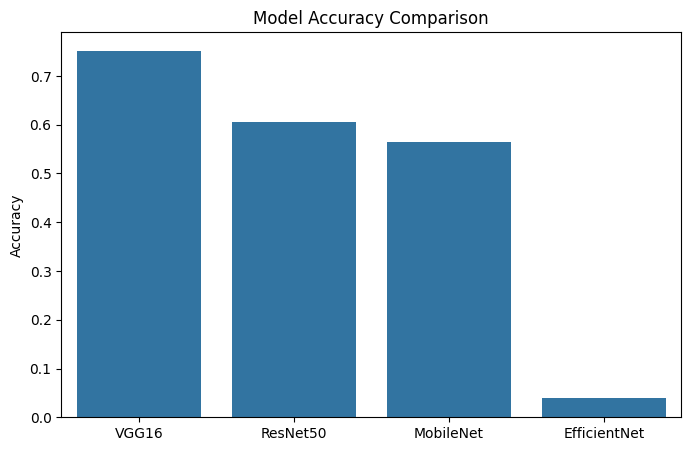

In [7]:
models = ["VGG16","ResNet50","MobileNet","EfficientNet"]

accuracies = [
    vgg_acc,
    resnet_acc,
    mobilenet_acc,
    efficient_acc
]

plt.figure(figsize=(8,5))

sns.barplot(x=models, y=accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [8]:
best_model = models[np.argmax(accuracies)]

print("Best Model:", best_model)

Best Model: VGG16


In [9]:
pred = efficient_model.predict(test_generator)

y_pred = np.argmax(pred, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step


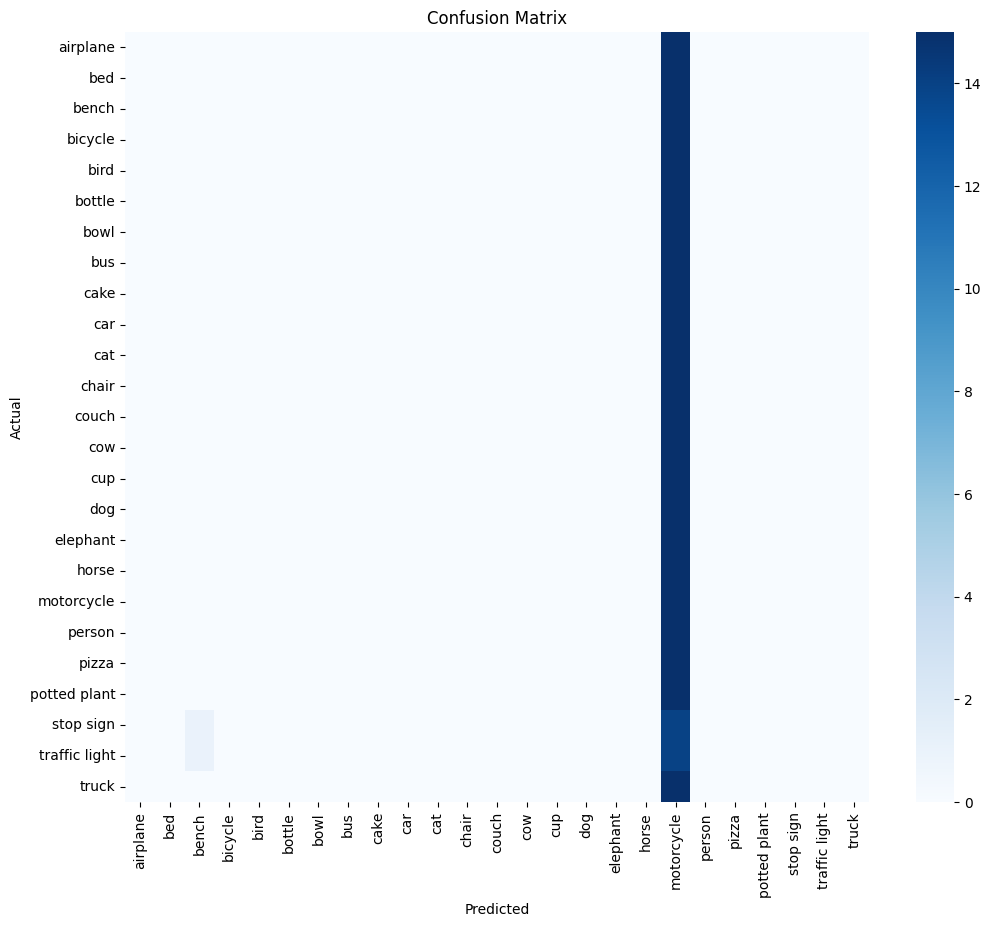

In [10]:
plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=test_generator.class_indices,
    yticklabels=test_generator.class_indices
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [11]:
print(
classification_report(
    y_true,
    y_pred,
    target_names=test_generator.class_indices.keys()
))

               precision    recall  f1-score   support

     airplane       0.00      0.00      0.00        15
          bed       0.00      0.00      0.00        15
        bench       0.00      0.00      0.00        15
      bicycle       0.00      0.00      0.00        15
         bird       0.00      0.00      0.00        15
       bottle       0.00      0.00      0.00        15
         bowl       0.00      0.00      0.00        15
          bus       0.00      0.00      0.00        15
         cake       0.00      0.00      0.00        15
          car       0.00      0.00      0.00        15
          cat       0.00      0.00      0.00        15
        chair       0.00      0.00      0.00        15
        couch       0.00      0.00      0.00        15
          cow       0.00      0.00      0.00        15
          cup       0.00      0.00      0.00        15
          dog       0.00      0.00      0.00        15
     elephant       0.00      0.00      0.00        15
        h

d:\VATHSAN\Gowtham\.venv-1\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\VATHSAN\Gowtham\.venv-1\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\VATHSAN\Gowtham\.venv-1\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
